<a href="https://colab.research.google.com/github/Shreyas-coding-master001/Machine_Learning_Seires/blob/main/Linear_Regression/Model_Creation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
print("hello")

hello


In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1 : all **Data Pre-Prossing** first then apply linear_regression model

In [91]:
df = pd.read_csv("/content/sample_data/Food_Delivery_Times.csv")

In [92]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [94]:
df.isnull().sum()
# df.isna.sum()   # Both same working

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [95]:
# Replacing the null values of categorical Data using first mode[0](mode = ["--", "--", "--"] )
cat_col = ["Weather", "Traffic_Level", "Time_of_Day"]

for col in cat_col:
  df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [96]:
# Replacing the null values of numeric data using mean or median
df['Courier_Experience_yrs'] = df["Courier_Experience_yrs"].fillna(df['Courier_Experience_yrs'].median())
# df['Courier_Experience_yrs'] = df["Courier_Experience_yrs"].fillna(df['Courier_Experience_yrs'].mean())


df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [97]:
# Removing the duplicate values
df.duplicated().sum()

np.int64(0)

In [98]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


# **Step 2 :** Perform EDA and get all relivent information

input : all data expect Delivery_Time_min

output : Delivery_Time_min

<Axes: xlabel='Order_ID', ylabel='Density'>

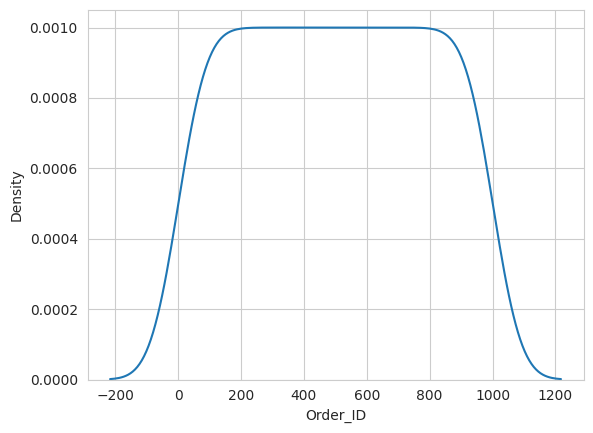

In [99]:
# sns.histplot(df['Order_ID'], bins=20)

sns.kdeplot(df['Order_ID'])

# This tell no good sqeuences of giving order_id nothing else 😭😭(timepass nikala isko)

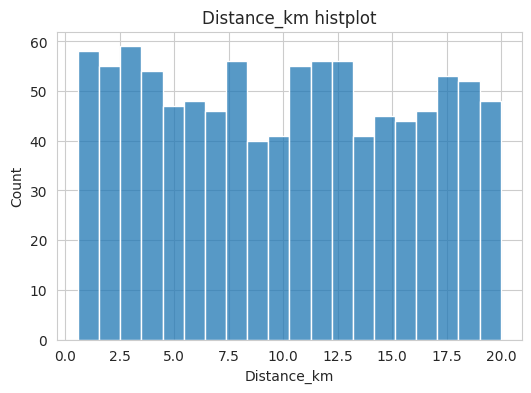

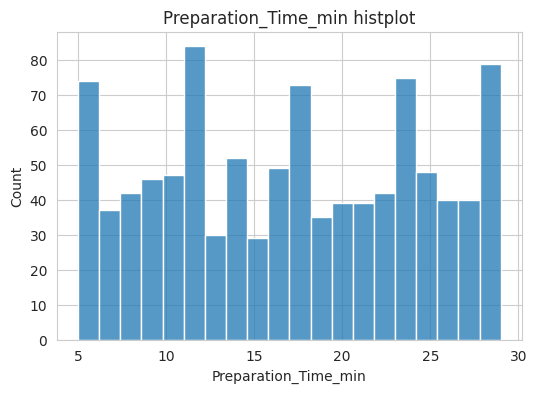

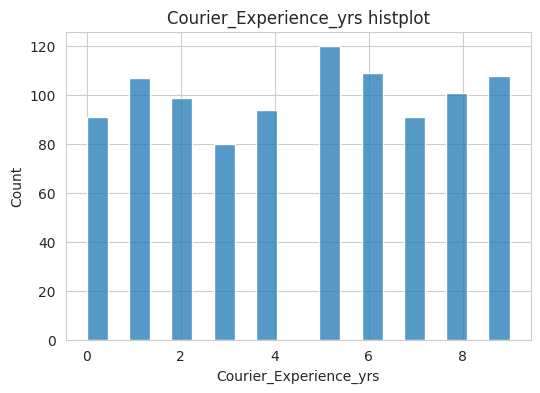

In [100]:
# All numeric columns Histplot and kdeplot
num_col = ["Distance_km", "Preparation_Time_min", "Courier_Experience_yrs"]

for col in num_col:
  plt.figure(figsize=(6,4))
  plt.title("{} histplot".format(col))
  sns.histplot(df[col], bins=20)
  plt.show()

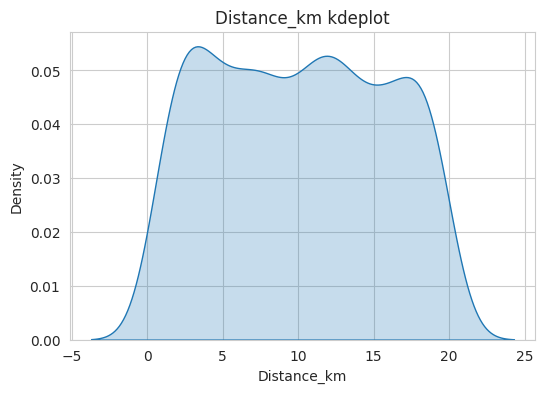

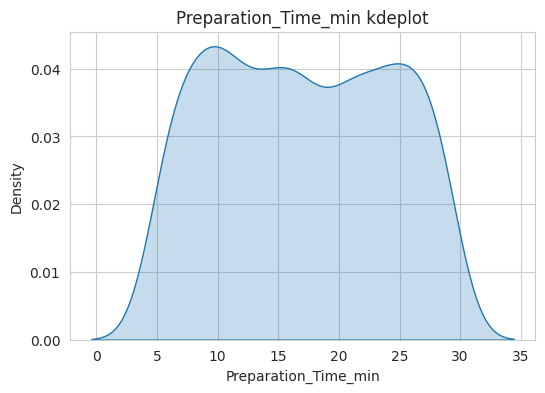

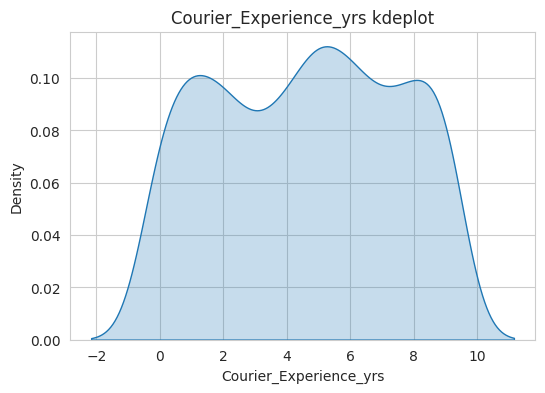

In [101]:
for col in num_col:
  plt.figure(figsize=(6,4))
  plt.title("{} kdeplot".format(col))
  sns.kdeplot(df[col], fill=True)
  sns.set_style("whitegrid")
  plt.show()

# **Information I GOT**

1.] `No change in Data`

2.] In **distance_km** : `0-5km most orders` && `around 15km least orders`

3.] In **Preparation_Time_min** : `Most orders come from 10mins` && `least orders are from 20mins`

4.] In **Courier_Experience_yrs** : `Most are from 4-5` && `least are from 2-4`


**Personal**

*   So best after 4 years of experience
*   Mostly good, steady throughout good spread




---



# **Now For Categorical Data**

In [102]:
df['Courier_Experience_yrs'].nunique()

# Personal : if < 5 then categorical else numerical

10

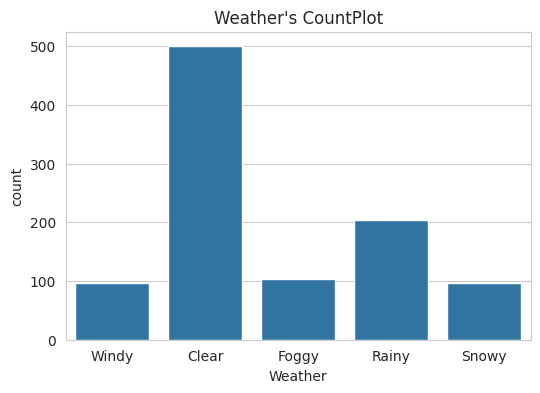

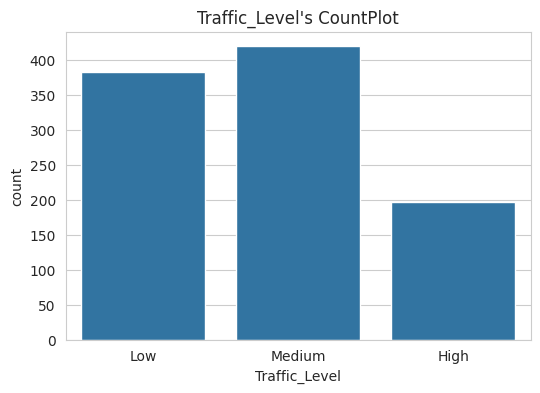

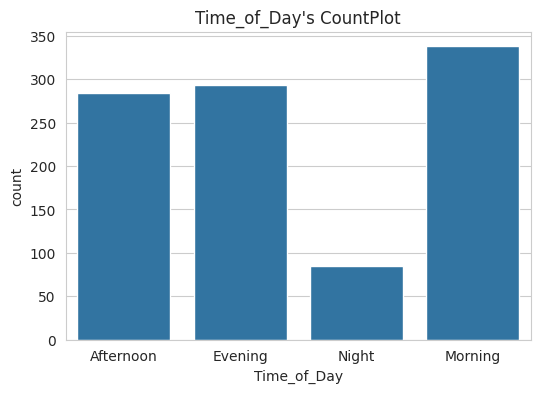

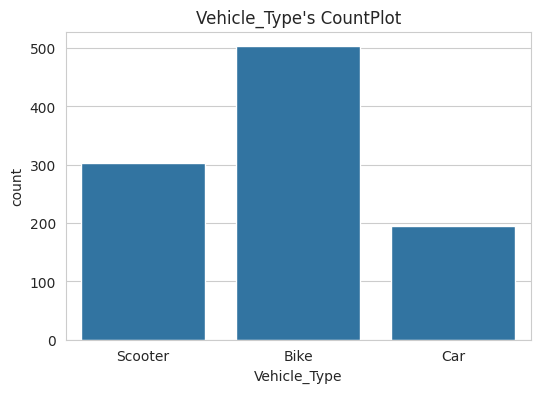

In [103]:
cat_col = ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]

for col in cat_col:
  plt.figure(figsize=(6,4))
  sns.countplot(data=df, x=col)
  plt.title(f"{col}'s CountPlot")
  plt.show()

# **Information I got**

1.   `Weather` : Mostly asked when **clear**
2.   `Traffic_Level` : Mostly asked when **medium and low traffic** and verly least in **high**
3.   `Time_of_Day`: Order -> **Morning**(Very high) -> **Evening & Afternoon**(high) -> **night**(very low)
4.   `Vehical_Type` : Bike is **mostly commonly** used









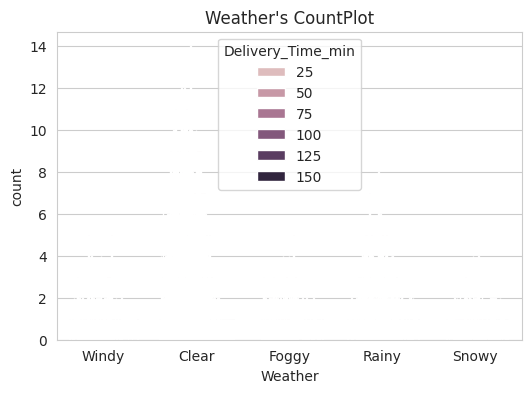

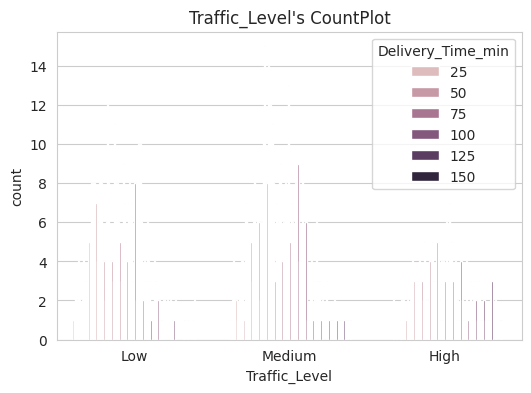

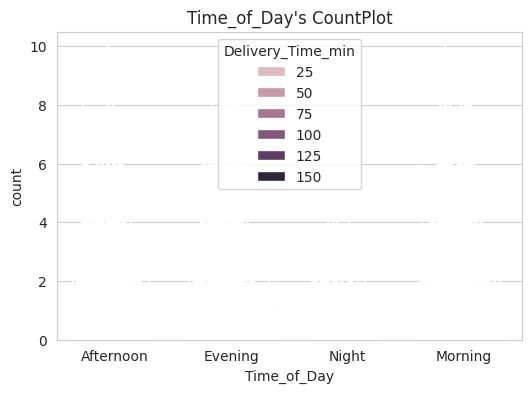

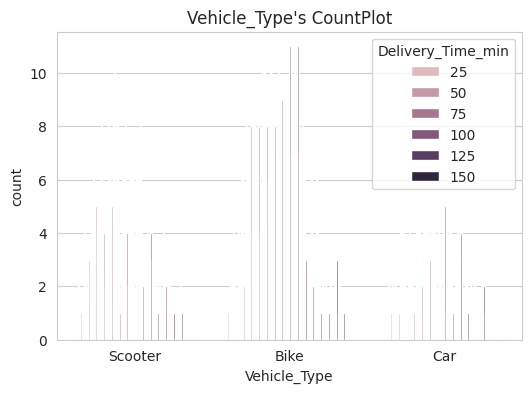

In [104]:
for col in cat_col:
  plt.figure(figsize=(6,4))
  sns.countplot(data=df, x=col, hue=df["Delivery_Time_min"])
  plt.title(f"{col}'s CountPlot")
  plt.show()

# **Should not Apply coutplot for categorical and numerical**

# **Remaing to apply boxplot**

In [105]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [106]:
df_my_copy = df.copy()
df_label = df.copy()
df_one = df.copy()

In [107]:
# Applying Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_my_copy['Traffic_Level'] = le.fit_transform(df['Traffic_Level']) #This in my personal encoding for categorical

In [108]:
df_my_copy.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,1,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,2,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,1,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,2,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,1,Morning,Bike,16,5.0,68


In [109]:
from numpy import dtype
le1 = LabelEncoder()

for col in cat_col:
  df_label[col] = le1.fit_transform(df[col])

In [110]:
df_label.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,4,1,0,2,12,1.0,43
1,738,16.42,0,2,1,0,20,2.0,84
2,741,9.52,1,1,3,2,28,1.0,59
3,661,7.44,2,2,0,2,5,1.0,37
4,412,19.03,0,1,2,0,16,5.0,68


In [111]:
# Applying One-hot encoding
df_one = pd.get_dummies(data=df_one, columns=cat_col, dtype=int)

In [112]:
df_one.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,738,16.42,20,2.0,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,741,9.52,28,1.0,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,661,7.44,5,1.0,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,412,19.03,16,5.0,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0


In [117]:
# new_col = cat_col.remove("Traffic_Level")

df_my_copy = pd.get_dummies(data=df_my_copy, columns=cat_col, dtype=int)

In [118]:
df_my_copy.head()

,Order_ID,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,1,12,1.0,43,0,0,0,0,1,1,0,0,0,0,0,1
1,738,16.42,2,20,2.0,84,1,0,0,0,0,0,1,0,0,1,0,0
2,741,9.52,1,28,1.0,59,0,1,0,0,0,0,0,0,1,0,0,1
3,661,7.44,2,5,1.0,37,0,0,1,0,0,1,0,0,0,0,0,1
4,412,19.03,1,16,5.0,68,1,0,0,0,0,0,0,1,0,1,0,0


# **Perform Feature Selection I am bored**

# **Now It is Ready to apply for ML model**

In [120]:
My_features = df_my_copy.drop(columns=["Order_ID", "Delivery_Time_min"])
My_target = df_my_copy["Delivery_Time_min"]

In [124]:
# My_features
My_target

,Delivery_Time_min
0,43
1,84
2,59
3,37
4,68
...,...
995,54
996,71
997,81
998,55


# **This is my personally though model which will perform better**

In [125]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(My_features, My_target, random_state=42)

In [126]:
from sklearn.linear_model import LinearRegression

my_model = LinearRegression()

my_model.fit(x_train, y_train)

LinearRegression()

# **This are completely from label and one-hot encoded models**

In [127]:
My_features_one = df_one.drop(columns=["Order_ID", "Delivery_Time_min"])
My_target_one = df_one["Delivery_Time_min"]

x_train_one, x_test_one, y_train_one, y_test_one = train_test_split(My_features_one, My_target_one, random_state=42)

my_model_one = LinearRegression()
my_model_one.fit(x_train_one, y_train_one)

My_features_label = df_label.drop(columns=["Order_ID", "Delivery_Time_min"])
My_target_label = df_label["Delivery_Time_min"]

x_train_label, x_test_label, y_train_label, y_test_label = train_test_split(My_features_label, My_target_label, random_state=42)

my_model_label = LinearRegression()
my_model_label.fit(x_train_label, y_train_label)

LinearRegression()